In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import seaborn as sns
import pandas as pd

I0000 00:00:1785145352.245772  101652 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785145352.327775  101652 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785145354.519151  101652 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
train_df = pd.read_csv("../Dataset/train_metadata.csv")
valid_df = pd.read_csv("../Dataset/valid_metadata.csv")
test_df = pd.read_csv("../Dataset/test_metadata.csv")

# Class Distribution

/tmp/ipykernel_101652/1618615521.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


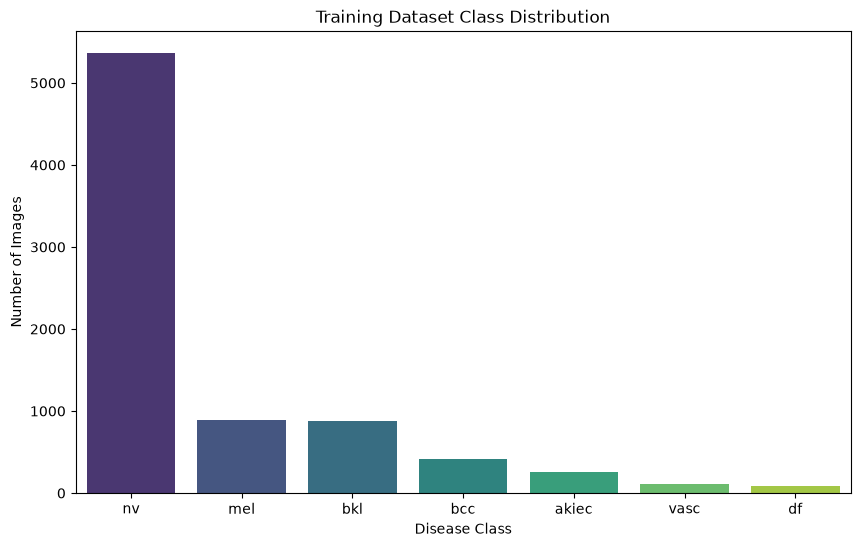

In [3]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=train_df,
    x="dx",
    order=train_df["dx"].value_counts().index,
    palette="viridis"
)

plt.title("Training Dataset Class Distribution")
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")

plt.show()

In [4]:
class_percentage = train_df["dx"].value_counts(normalize=True) * 100

print(class_percentage.round(2))

dx
nv       66.95
mel      11.11
bkl      10.97
bcc       5.13
akiec     3.27
vasc      1.42
df        1.15
Name: proportion, dtype: float64


# Pie Chart

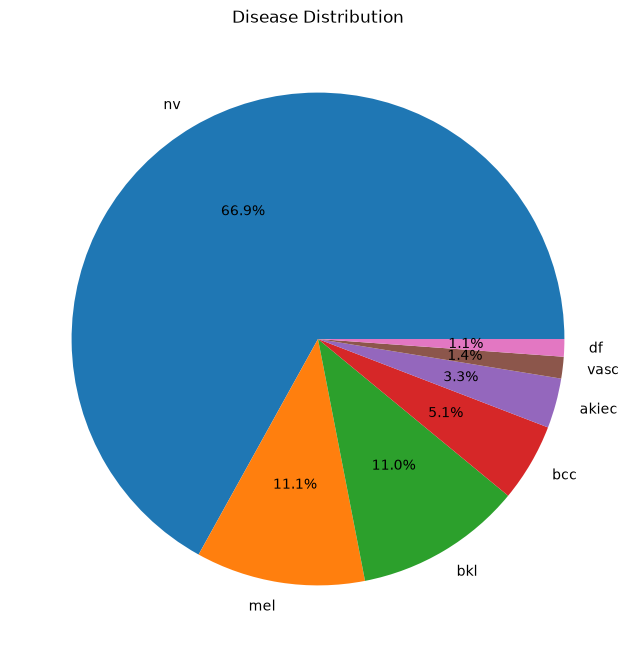

In [5]:
plt.figure(figsize=(8,8))

train_df["dx"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Disease Distribution")

plt.show()

# Pixel Intensity Analysis

In [6]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

train_df["label"] = label_encoder.fit_transform(train_df["dx"])
valid_df["label"] = label_encoder.transform(valid_df["dx"])
test_df["label"] = label_encoder.transform(test_df["dx"])

print(label_encoder.classes_)

['akiec' 'bcc' 'bkl' 'df' 'mel' 'nv' 'vasc']


In [7]:
IMG_SIZE = (224,224)

def process_image(path, label):

    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [ ]:
# Training Dataset
train_dataset = tf.data.Dataset.from_tensor_slices(
    (train_df["path"].values, train_df["label"].values)
)

train_dataset = train_dataset.map(process_image)

# Validation Dataset
valid_dataset = tf.data.Dataset.from_tensor_slices((valid_df["path"].values, valid_df["label"].values))

valid_dataset = valid_dataset.map(process_image)

# Test Dataset
test_dataset = tf.data.Dataset.from_tensor_slices((test_df["path"].values, test_df["label"].values))

test_dataset = test_dataset.map(process_image)

E0000 00:00:1785145357.509938  101652 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [ ]:
pixel_values = []

for images, labels in train_dataset.take(10):

    pixel_values.append(images.numpy().flatten())

In [10]:
pixel_values[0]

np.float32(0.49915683)

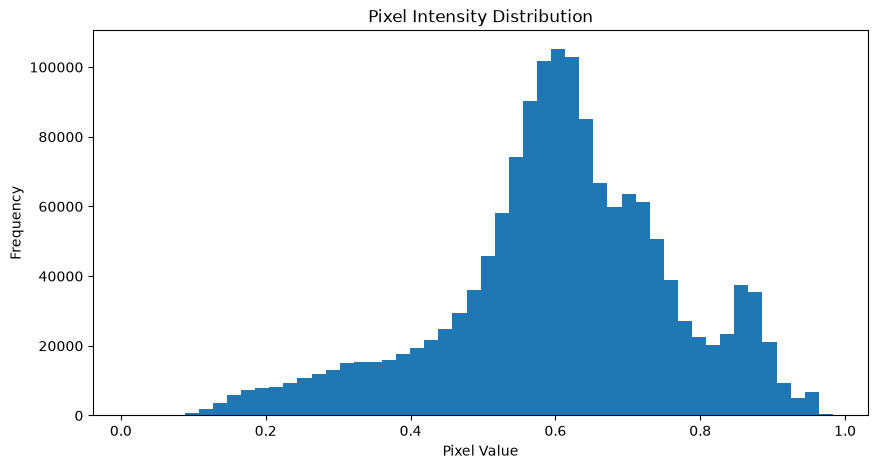

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(pixel_values, bins=50)

plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")

plt.show()

In [12]:
print("Minimum Pixel Value :", np.min(pixel_values))
print("Maximum Pixel Value :", np.max(pixel_values))
print("Mean Pixel Value :", np.mean(pixel_values))

Minimum Pixel Value : 0.01043328
Maximum Pixel Value : 0.9832455
Mean Pixel Value : 0.6054837


# Image Augmentation Comparison

In [13]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.2)
])

In [14]:
for images, labels in train_dataset.take(1):

    image = images[0]
    break

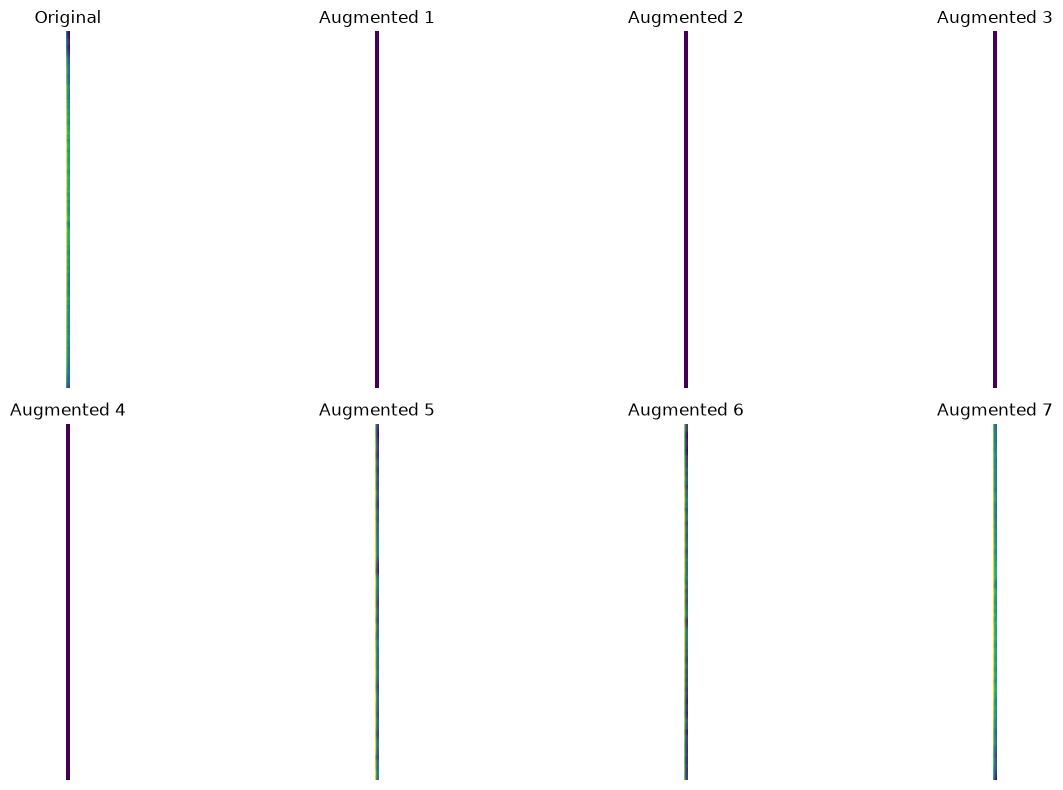

In [15]:
plt.figure(figsize=(15, 8))

# Original Image
plt.subplot(2, 4, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

# Augmented Images
for i in range(2, 9):

    augmented = data_augmentation(
        tf.expand_dims(image, axis=0),
        training=True
    )

    plt.subplot(2, 4, i)
    plt.imshow(augmented[0])
    plt.title(f"Augmented {i-1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Class-wise Image Characteristics

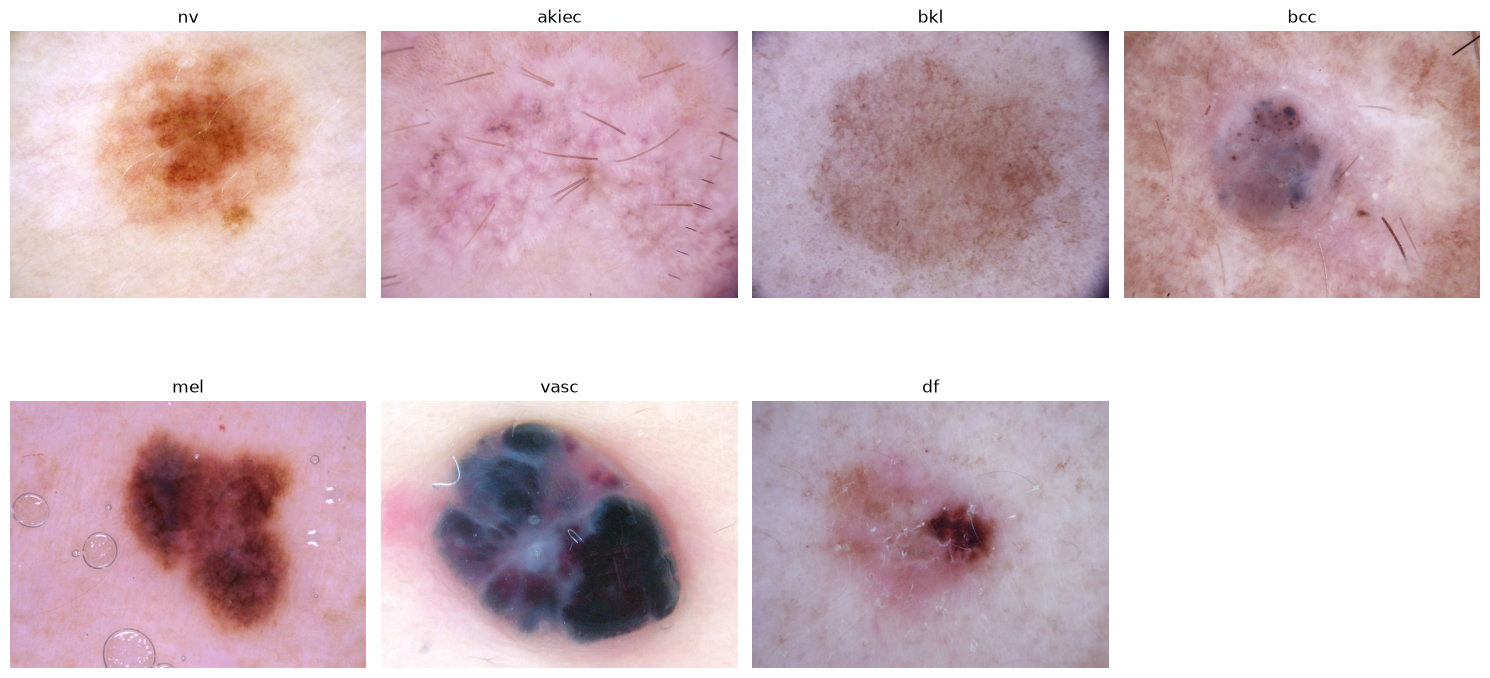

In [16]:
disease_names = train_df["dx"].unique()

plt.figure(figsize=(15,8))

for i, disease in enumerate(disease_names):

    sample = train_df[
        train_df["dx"] == disease
    ].sample(1)

    image = plt.imread(sample.iloc[0]["path"])

    plt.subplot(2,4,i+1)

    plt.imshow(image)

    plt.title(disease)

    plt.axis("off")

plt.tight_layout()

plt.show()

### Display Multiple Images Per Class

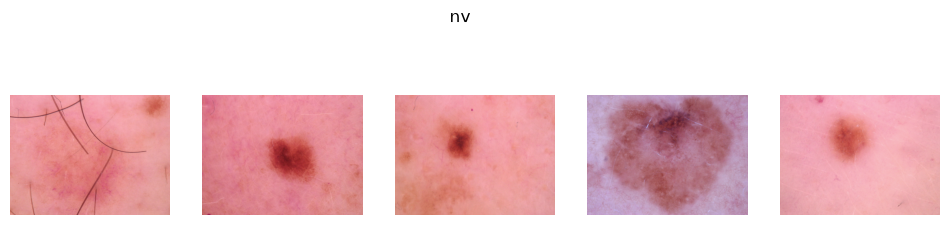

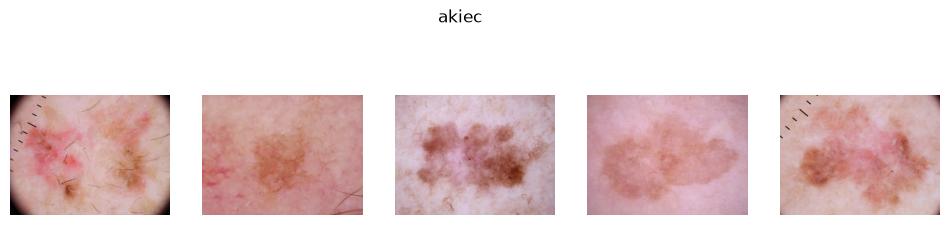

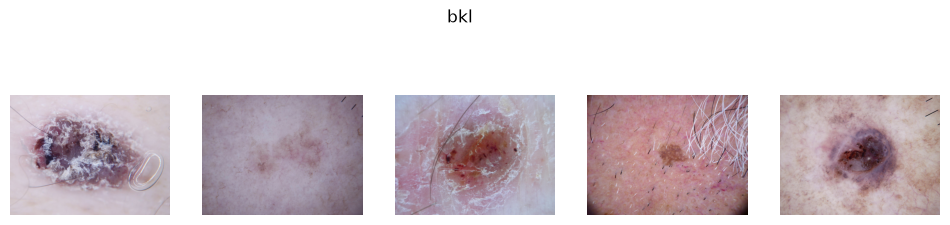

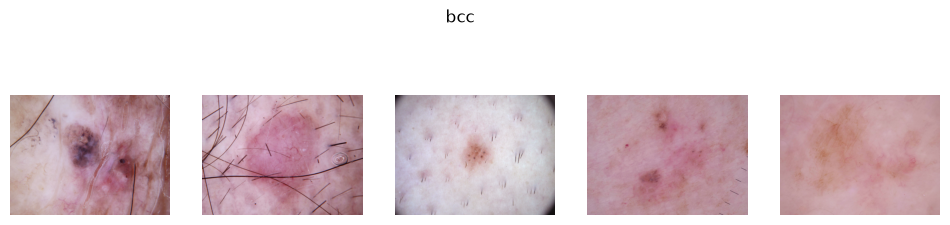

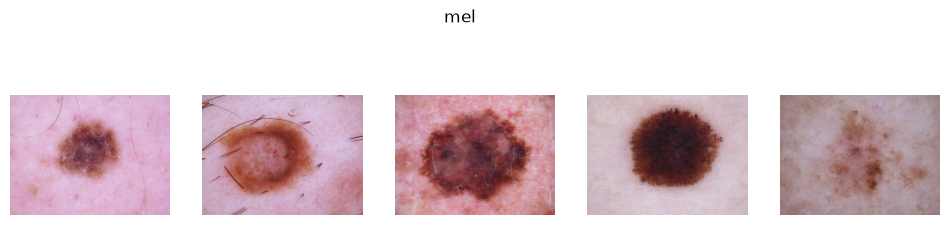

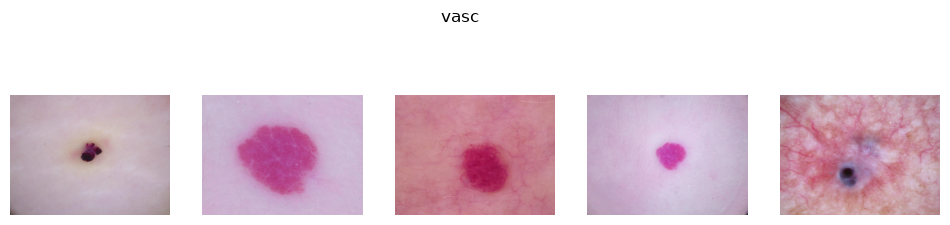

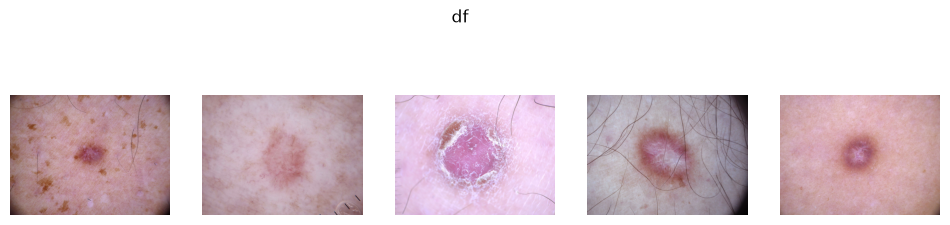

In [ ]:
classes = train_df["dx"].unique()

for disease in classes:

    plt.figure(figsize=(12,3))

    samples = train_df[train_df["dx"] == disease].sample(5)

    for i, (index, row) in enumerate(samples.iterrows()):

        image = plt.imread(row["path"])

        plt.subplot(1,5,i+1)

        plt.imshow(image)

        plt.axis("off")

    plt.suptitle(disease)

    plt.show()

### Image Dimension Verification

In [18]:
for images, labels in train_dataset.take(1):

    print("Batch Shape :", images.shape)

    print("Single Image Shape :", images[0].shape)

Batch Shape : (224, 224, 3)
Single Image Shape : (224, 3)
